In [1]:
import scipy
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.integrate import odeint
import numpy as np

In [2]:
# a) Define variables used in Inverse Power Law:

phi = var(r'φ') # scalar field
k = 1
#Mpl = 1 # Reduced planck mass units
alp = var(r'α') # steepness of inverse power law
alp = 4
M = var('M') # Mass scale of IPL
N = var('N') # N units
beta = var(r'β') # coupling variable


In [3]:
# Expression for V and derivative
def V(M,phi):
    return (M^(4+alp))/phi^alp

def dVdphi(M,phi):
    return -alp*V(M,phi)/phi

In [4]:
show(V(M,phi))

M^8/φ^4

In [5]:
# Define cosmological parameters
h = 0.7
ohm_m = 0.31 # Current approximate value for Ωm 
Ho = 2.1332e-42*h*4.10677e-19 # Hubble constant in reduced plank mass units
rho_c0 = (3*Ho^2/(k^2)) # current critical energy density
A = 0.65
M_val = ((rho_c0*(8*np.pi)^(alp/2))^(1/(alp+4)))*A # Value set for M
gam = 1
beta =0
Ni = 0 

The aim of the`CoupledSteinhardt(X,N)` function is to output our primed Klein Gordon Equation as two first order differential equations for $φ'$ and $φ''$ in terms of X where `X[0]` = φ and `X[1]` = φ' for a value of $N$. We obtain outputs for $φ'$ and $φ''$ by:
1. Calculating the scale factor $a$ using $a = \exp{N}$
2. Generating $ρ_m$ using $ρ_m = ρ_{c,0}Ω_m(aa_i)^{-3}\exp(\beta\phi)$
3. Generating $V$ and $\frac{dV}{dφ}$ using `X[0]`
4. Calculating $H^2$ and $\frac{\dot{H}}{H^2}$ using previous parameters and `X[1]`
5. Pulling everything together

In [6]:
def CoupledSteinhardt(X,N):
    a = exp(N) # N = ln(a)
    ai = exp(Ni)
    rho_m = rho_c0*ohm_m*(a*ai)**(-3)*np.exp(beta*X[0])
    Vfunc = V(M_val,X[0])
    dVfunc = dVdphi(M_val,X[0])

    H2 = (rho_m + Vfunc)/(3-0.5*(X[1])**2)
    HdotH2 = -0.5*((X[1])**2+ gam*rho_m/H2)
    x1prime = X[1]
    x2prime = -(3+HdotH2)*X[1] - dVfunc/H2- beta*rho_m/H2
    #show(x2prime)
    return [x1prime,x2prime]

In [7]:
Ni=0
show(CoupledSteinhardt([1,0],0))

[0, np.float64(11.817980304632691)]

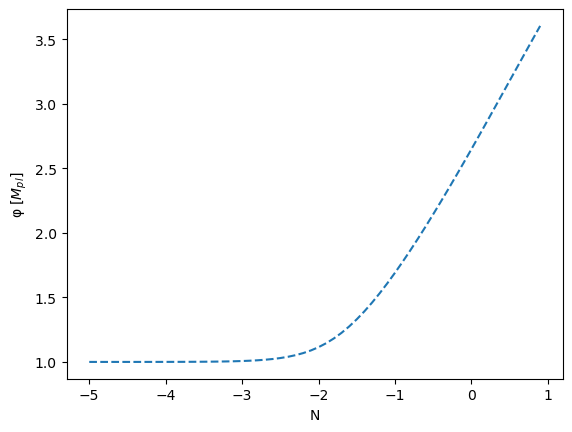

In [8]:
# Test to make sure odeint integrates CoupledSteinhardt correctly:
# Set φ = 1 and φ' = 0 in this test

# Also set range of N
Nrange = np.arange(-5,1,.1) # N values
z_values = exp(-Nrange) # z+1 = exp(-N)
Ni = 0

'''
Use scipy odeint to numerically integrate Klein Gordon for a scalar field where φ_i = 1 and φ'_i = 0
'''
sol = odeint(CoupledSteinhardt,[1,0],t=Nrange)
phi_sol = sol[:,0] # φ solutions
phi_prime = sol[:,1] # φ' solutions

# Visualise solutions
plt.xlabel("N")
plt.ylabel(r"φ $[M_{pl}]$")
plt.plot(Nrange,phi_sol,'--')

In [9]:
# Other cosmological constants
def other_parameters(fi,dfi,N):
    '''
    Function that determines other cosmological parameters using
    fi = φ
    dfi = φ'
    N => N = ln(a)
    See supporting key file for information on parameters calculated
    '''
    a = exp(N) # N = ln(a)
    ai = exp(Ni)
    z = exp(-N)-1
    rho_m = rho_c0*ohm_m*(a*ai)**(-3)*np.exp(beta*fi) #1e7 is that initial pmi value
    Pot = V(M_val,fi)
    H2 = (rho_m + Pot)/(3-1/2*dfi**2)
    rho_φ = 0.5*(dfi**2*H2) + Pot #Energy density of φ (ρ_φ)
    #ratio_rho = rho_φ/rho_m
    test = rho_m*a**3*np.exp(-beta*fi)
    O_φ = ((k**2)/3)*(rho_φ/H2) # Ωφ
    O_m = 1-O_φ
    
    Pφ = 0.5*(dfi**2*H2) - Pot
    Y_φ = (Pφ+rho_φ)/rho_φ
    w = Pφ/rho_φ #Equation of State wΦ
    weff = Pφ/(rho_φ +rho_m)
    return z,rho_φ,Pφ,O_φ,O_m,w,Y_φ,rho_m,weff,test

In [10]:
# Now using numerical solutions for φ and φ' for a scalar field where φ_i = 1 and φ'_i = 0 that was generated previously
z,rho_s,P,O_Q,O_m,w,Y_Q,rho_m,weff,test = other_parameters(phi_sol,phi_prime,Nrange)

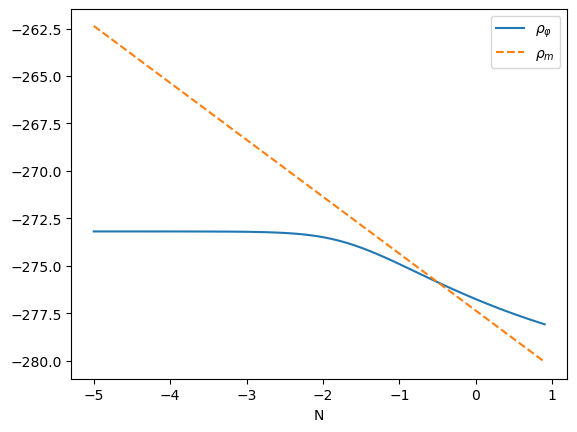

In [11]:
# Plots of cosmological parameters vs N  - add or remove # to view plots

#plt.plot(Nrange,phi_sol, label  =r"φ")
#plt.plot(Nrange,phi_prime, label  =r"φ'")
plt.plot(Nrange,log(rho_s),label=r"$ρ_φ$")
plt.plot(Nrange,log(rho_m),label=r"$ρ_m$",ls='--')
#plt.plot(Nrange,P,label=r"P_φ") 
#plt.plot(Nrange,O_Q,label=r"Ω_φ") 
#plt.plot(Nrange,w,label=r"ω") 
plt.xlabel("N")
#plt.xlim([-1,1])
plt.legend()
#plt.savefig(r"log of $ρ_φ$ and $ρ_m$ for Q = {}.png".format(np.round(Q,3))) 

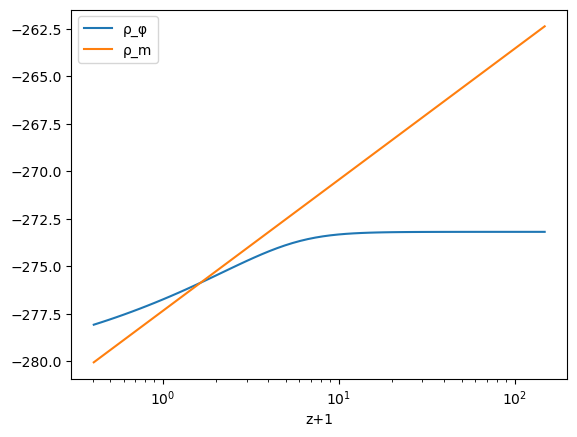

In [12]:
# Plots of cosmological parameters vs z+1  - add or remove # to view plots
Z = z+1
#plt.plot(Z,phi_sol, label  =r"φ")
#plt.plot(Z,phi_prime, label  =r"φ'")
plt.plot(Z,log(rho_s),label=r"ρ_φ")
plt.plot(Z,log(rho_m),label=r"ρ_m")
#show(Y_Q)
#plt.plot(Z,(Y_Q),label=r"γ_φ")
#plt.plot(Z,ratio_O,label = r"ratio_Ω")
#plt.plot(Z,P,label=r"P_φ")
#show(max(O_Q))
#show(max(Y_Q))
#plt.plot(Z,log(O_Q),label=r"Ω_φ") 
#plt.plot(Z,log(O_m),label=r"Ω_m")
#plt.plot(Z,O_m/O_Q,label=r"ratio_Ω")
#plt.plot(Z,w,label=r"ω") 
plt.xlabel("z+1")
plt.xscale('log')
plt.legend()

# Evolution of 6 cosmological parameters for different $\beta$
In the following cell we simulate the evolution of cosmological parameters over a chosen range of $N$ while changing the strength of the coupling $\beta$. We then plot the evolution of the parameters as one figure. We only show the evolution of 7 cosmological parameters and these are: the scalar field, $\phi$, the potential of the scalar field, $V(\phi)$, the effective equation of state of the field, $\omega_f$, the energy densities of the scalar field and matter ($\rho_φ$,$\rho_m$) in logarithmic scales and the fractional densities of the scalar field and matter ($\Omega_φ$, $\Omega_m$). 

Using the results from our study on normal quintessence, we choose  $φ_i = 0.9$ and  $φ_i ' = 0$. The numerical solutions of the cosmological parameters are generated inside the for loop using odeint as we did above but with different levels of coupling including no coupling. Once we have generated this data for the set range of N, we substitute φ and φ' into the other_parameters function to produce the remaining cosmological parameters. We do this for all values of $\beta$  to observe how the coupling influences the evolution of the cosmological parameters. For each $\beta$ value, each parameter is then assigned to a subplot using the function xaxis as we did for normal quintessence. 

The xaxis function takes four inputs: x, label, i, ls. x is the x-axis and so must be either Nrange or Z, where Z = z+1 and in logarithmic scales. label is where you enter the label for the x_axis. i is the same i that is in the for loop so are our values of $\beta$. ls is the linestyle of the plots. This is needed so that each coupling solution a different linestyle. 

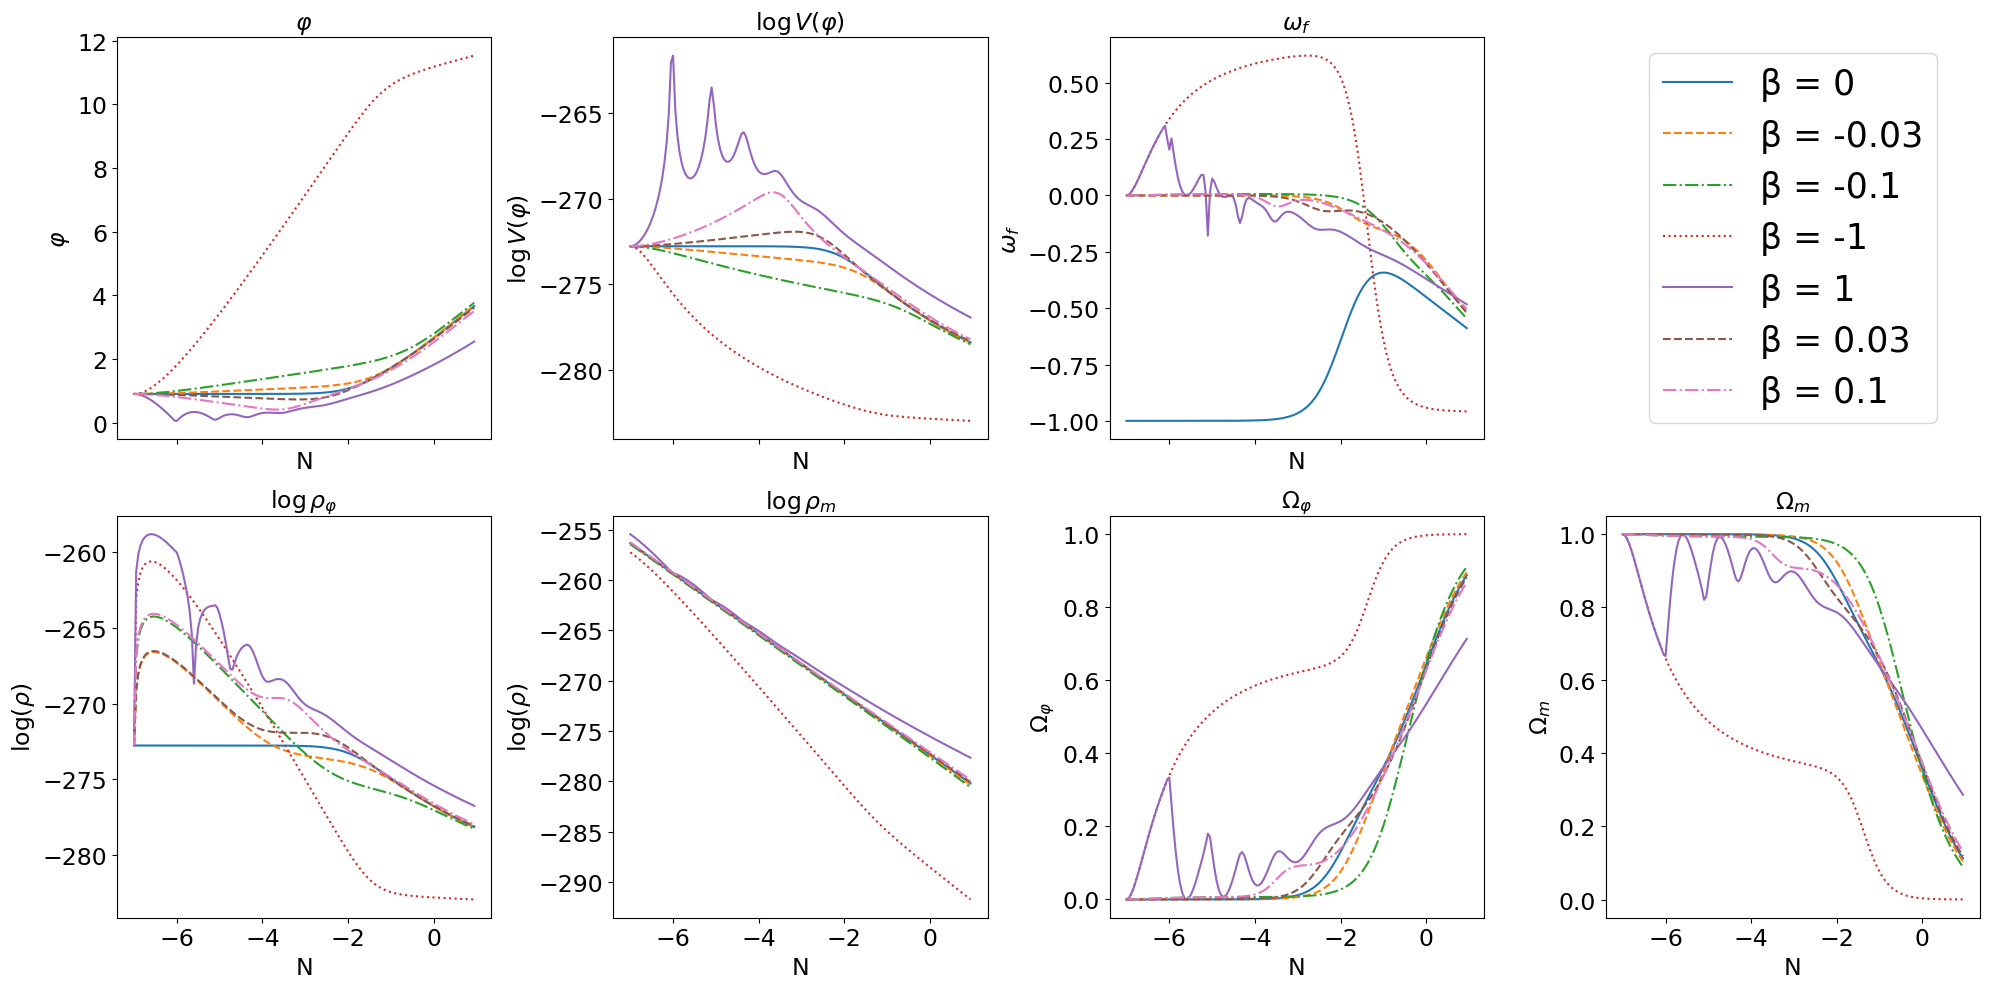

In [13]:
Nrange = np.arange(-7,1,.05)
Q_list = []
Ni = Nrange[0]
w_list = []
from itertools import cycle
StyleList = ['solid','dashed','dashdot','dotted']
cmap = ['red','blue','green']
lines = cycle(StyleList)
colours = cycle(cmap)
fs = 17

fig, axs = plt.subplots(2,4, figsize=(20, 10),sharex=True)
def xaxis(x,label,i,ls):        
    #axs[0,0].set_yscale('log')
    axs[0,0].plot(x,solQ[:,0],label=r"$φ_i$ = {}".format(i),linestyle = "{}".format(ls))
    axs[0,0].set_title(r"$φ$",fontsize = fs)
    axs[0,0].set_xlabel(xlabel = "{}".format(label),fontsize = fs)
    axs[0,0].set_ylabel(r"$φ$",fontsize = fs)
    axs[0,0].tick_params(axis='both', which='major', labelsize=fs)
    if label == "z+1":
        axs[0,0].set_xscale('log')
        axs[0,0].xaxis.set_inverted(True)
    
    
    #axs[0,1].plot(x,solQ[:,1],label=r"$φ_i$= {}".format(i),linestyle = "{}".format(ls))
    #axs[0,1].set(ylabel = r"$φ$'$[M_{pl}]$", xlabel = "{}".format(label),title=r"$φ$' vs {}".format(label))

    axs[0,1].plot(x,log(V(M_val,solQ[:,0])),label=r"$φ_i$= {}".format(i),linestyle = "{}".format(ls))
    axs[0,1].set_title(r"$\log V(φ)$",fontsize = fs)
    axs[0,1].set_xlabel(xlabel = "{}".format(label),fontsize = fs)
    axs[0,1].set_ylabel(ylabel = r"$\log V(φ)$",fontsize = fs)
    axs[0,1].tick_params(axis='both', which='major', labelsize=fs)
        
    #axs[0,2].plot(x,P,label=r"$φ_i$ = {}".format(i))
    #axs[0,2].set(ylabel = r"P_φ", xlabel = "{}".format(label),title=r"$P_φ$ vs {}".format(label))
    #axs[0,2].legend()
    
    #axs[1,0].plot(x,rho, linestyle = "{}".format(ls))
    axs[1,0].plot(x,log(rho), linestyle = "{}".format(ls))
    #axs[1,0].plot(x,log(rho_m),label=r"$\rho_m$",linestyle = "{}".format(ls),color = 'black')
    axs[1,0].set_title(r"$\log ρ_φ$",fontsize = fs)
    axs[1,0].set_xlabel(xlabel = "{}".format(label),fontsize = fs)
    axs[1,0].set_ylabel(r"log($ρ$)",fontsize = fs)
    axs[1,0].tick_params(axis='both', which='major', labelsize=fs)
    #rho_m_list += axs[1,0].plot(x,log(rho_m),label=r"$\rho_m$",color='black')

    #axs[1,1].plot(x,log(rho), linestyle = "{}".format(ls))
    axs[1,1].plot(x,log(rho_m),label=r"$\rho_m$",linestyle = "{}".format(ls))
    axs[1,1].set_title(r"$\log ρ_m$",fontsize = fs)
    axs[1,1].set_xlabel(xlabel = "{}".format(label),fontsize = fs)
    axs[1,1].set_ylabel(r"log($ρ$)",fontsize = fs)
    axs[1,1].tick_params(axis='both', which='major', labelsize=fs)
    
    
    axs[1,2].plot(x,O_Q,label=r"$φ_i$ = {}".format(i),linestyle = "{}".format(ls))
    axs[1,2].set_title(r"$Ω_φ$ ",fontsize = fs)
    axs[1,2].set_xlabel(xlabel = "{}".format(label),fontsize = fs)
    axs[1,2].set_ylabel(r"$Ω_φ$",fontsize = fs)
    axs[1,2].tick_params(axis='both', which='major', labelsize=fs)
    #axs[1,1].grid(True)
    #axs[1,2].set_xlim(-1,0)
    
    axs[1,3].plot(x,O_m,label=r"$φ_i$ = {}".format(i),linestyle = "{}".format(ls))
    axs[1,3].set_title(r"$Ω_m$",fontsize = fs)
    axs[1,3].set_xlabel(xlabel = "{}".format(label),fontsize = fs)
    axs[1,3].set_ylabel(r"$Ω_m$",fontsize = fs)
    axs[1,3].tick_params(axis='both', which='major', labelsize=fs)
    #axs[1,2].grid(True)

    #axs[0,2].plot(x,w,label=r"$φ_i$= {}".format(i),linestyle = "{}".format(ls))
    

    if i == 0:
        '''
        This checks to see whether β is zero or not. If it zero, we show ω rather than ωf. 
        '''
        axs[0,2].plot(x,w,label=r"$φ_i$= {}".format(i),linestyle = "{}".format(ls))
        #axs[0,2].set( xlabel = "{}".format(label),title=r"ω vs {}".format(label))
    else:
        axs[0,2].plot(x,weff,label=r"$φ_i$= {}".format(i),linestyle = "{}".format(ls))
        #axs[0,2].set( xlabel = "{}".format(label),title=r"$ω_f$ vs {}".format(label))
        axs[0,2].set_title(r"$ω_f$ ",fontsize = fs)
        axs[0,2].set_xlabel(xlabel = "{}".format(label),fontsize = fs)
        axs[0,2].set_ylabel(ylabel ="$ω_f$",fontsize = fs)
        axs[0,2].tick_params(axis='both', which='major', labelsize=fs)

        
    #axs[0,2].legend()
    #axs[0,2].plot(x,weff,label=r"$φ_i$= {}".format(i),linestyle = "{}".format(ls))
    #axs[0,2].set( xlabel = "{}".format(label),title=r"$ω_f$ vs {}".format(label))

    if label == "z+1":
        axs[0,0].set_xscale('log')
        axs[0,0].xaxis.set_inverted(True)
        secax0 = axs[0,0].twiny()
        secax0.set_xlim(Nrange[0],Nrange[-1])
        secax0.set_xlabel('N')
    
#Q_values = -np.arange(0,1,.1) # These are different initial values of coupling constant Q
Q_values = [0,-0.03,-0.1,-1,1,0.03,0.1]
#Q_values = [-0.03,-0.1,-1,1,0.03,0.1]
#Q_values = [-1]
#Q_values = [-1,-0.1,-0.03,0,0.03,0.1,1]
#Q_values = [0]
#Q_values = [-1.5,-2]

for i in Q_values:
    Ni = Nrange[0]
    Ni=0
    #Q_list.append("$φ_i$ = {}".format(np.round(i,4)))
    #solQ = odeint(CoupledSteinhardt,[i,0],t=Nrange)
    beta = i
    Q_list.append(r"β = {}".format(np.round(i,4)))
    solQ = odeint(CoupledSteinhardt,[.9,0],t=Nrange) # change 0.5 back to i
    potentials = (V(M_val,solQ[:,0]))
    '''When I generate solutions, I also find the corresponding z,ωφ,ρφ,Ωφ,Pφ values for all initial Q values ranged. '''
    z,rho,P,O_Q,O_m,w,Y_Q,rho_m,weff,test = other_parameters(solQ[:,0],solQ[:,1],Nrange)
    w_list.append((i,round(max(w),3)))
    Z = z+1
    xaxis(Nrange,"N",i,next(lines)) # Here is where you can alter whether to view graphs w.r.t to N or z+1


# import matplotlib.patches as mpatches
# black_patch = mpatches.Patch(color='black', label=r"$\rho_m$") # Adds extra legend to rho plot for rho_m
# axs[1,0].legend(handles=[black_patch],fontsize = 20)

# Used to hide empty subplot and place legend inside this subplot
empty_ax = axs[0, 3]
empty_ax.axis('off') 
handles, labels = axs[0, 0].get_legend_handles_labels()
empty_ax.legend(handles, Q_list, loc='center', frameon=True,fontsize = 25)

fig.tight_layout()

fig.savefig(r"7 plots with ${}$ .png".format(Q_list))

The following cell uses the same code that we used above, except it only outputs a figure which displays $ρ_φ, ρ_m$ and $ω,ωf$ only. Otherwise the code executes in the same way. 

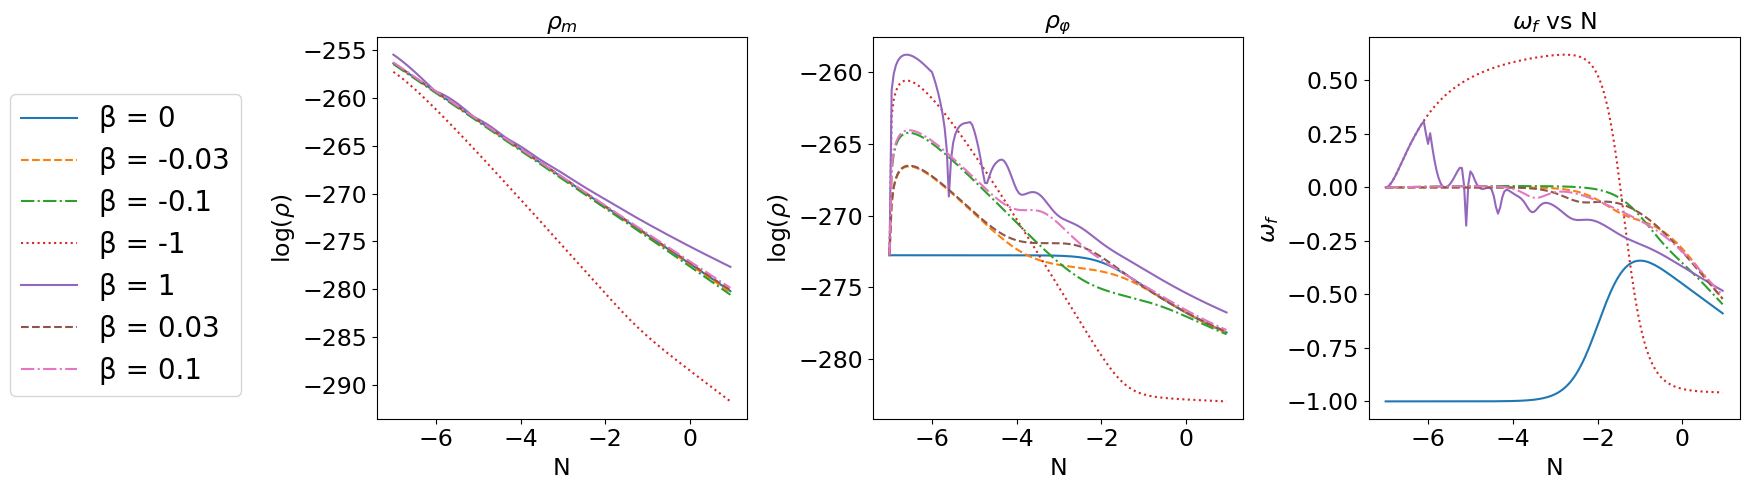

In [14]:
Nrange = np.arange(-7,1,.05)
Q_list = []
Ni = Nrange[0]
w_list = []
from itertools import cycle
StyleList = ['solid','dashed','dashdot','dotted']
cmap = ['red','blue','green']
lines = cycle(StyleList)
colours = cycle(cmap)
fs = 17
fig, axs = plt.subplots(1,3, figsize=(15, 5),sharex=True)
def xaxis(x,label,i,ls):        
    #axs[0].plot(x,log(rho),label=r"$\beta$ = {}: $\rho_φ$".format(beta), linestyle = "{}".format(ls))
    axs[0].plot(x,log(rho_m), label = r"$\beta$ = {}: $\rho_m$".format(beta),linestyle = "{}".format(ls))
    axs[0].set_title(r"$ρ_m$",fontsize = fs)
    #axs[0].set_title(r"$ρ_φ$ and $ρ_m$ when $\beta$ = {}".format(beta),fontsize = fs)
    axs[0].set_xlabel(xlabel = "{}".format(label),fontsize = fs)
    axs[0].set_ylabel(r"log($ρ$)",fontsize = fs)
    axs[0].tick_params(axis='both', which='major', labelsize=fs)

    axs[1].plot(x,log(rho),label=r"$\beta$ = {}: $\rho_φ$".format(beta), linestyle = "{}".format(ls))
    #axs[1].plot(x,log(rho_m), label = r"$\beta$ = {}: $\rho_m$".format(beta),linestyle = "{}".format(ls))
    axs[1].set_title(r"$ρ_φ$",fontsize = fs)
    #axs[0].set_title(r"$ρ_φ$ and $ρ_m$ when $\beta$ = {}".format(beta),fontsize = fs)
    axs[1].set_xlabel(xlabel = "{}".format(label),fontsize = fs)
    axs[1].set_ylabel(r"log($ρ$)",fontsize = fs)
    axs[1].tick_params(axis='both', which='major', labelsize=fs)

    #axs[0].legend(fontsize = 14)
    if i == 0:
        axs[2].plot(x,w,label=r"$\beta$= {}".format(i),linestyle = "{}".format(ls))
        #axs[0,2].set( xlabel = "{}".format(label),title=r"ω vs {}".format(label))
    else:
        axs[2].plot(x,weff,label=r"$\beta$= {}".format(i),linestyle = "{}".format(ls))
        #axs[1].set( xlabel = "{}".format(label),title=r"$ω_f$ vs {}".format(label))
        axs[2].set_title(r"$ω_f$ vs {}".format(label),fontsize = fs)
        axs[2].set_xlabel(xlabel = "{}".format(label),fontsize = fs)
        axs[2].set_ylabel(ylabel =r"$ω_f$",fontsize = fs)
        axs[2].tick_params(axis='both', which='major', labelsize=fs)

    # axs[1].plot(x,weff,label=r"$\beta$= {}".format(i),linestyle = "{}".format(ls))
    # axs[1].set( xlabel = "{}".format(label),title=r"ω_f vs {}".format(label))
    #axs[2].legend(fontsize = 14)

    if label == "z+1":
        axs[0].set_xscale('log')
        axs[0].xaxis.set_inverted(True)
        secax0 = axs[0].twiny()
        secax0.set_xlim(Nrange[0],Nrange[-1])
        secax0.set_xlabel('N')

# These are different initial values of coupling constant

#Q_values = -np.arange(0,1,.1) 
Q_values = [0,-0.03,-0.1,-1,1,0.03,0.1]
#Q_values = [-0.03,-0.1,-1,1,0.03,0.1]
#Q_values = [0,-0.03]
#Q_values = [1.5,2,3,4,5]
#Q_values = [-1,-0.1,-0.03,0,0.03,0.1,1]
#Q_values = [-1]

for i in Q_values:
    Ni = Nrange[0]
    Ni=0
    #Q_list.append("$φ_i$ = {}".format(np.round(i,4)))
    #solQ = odeint(CoupledSteinhardt,[i,0],t=Nrange)
    beta = i
    Q_list.append(r"β = {}".format(np.round(i,4)))
    solQ = odeint(CoupledSteinhardt,[.9,0],t=Nrange) # change 0.5 back to i
    potentials = (V(M_val,solQ[:,0]))
    '''When I generate solutions, I also find the corresponding z,ωφ,ρφ,Ωφ,Pφ values for all initial Q values ranged. '''
    z,rho,P,O_Q,O_m,w,Y_Q,rho_m,weff,test = other_parameters(solQ[:,0],solQ[:,1],Nrange)
    w_list.append((i,round(max(w),3)))
    Z = z+1
    xaxis(Nrange,"N",i,next(lines)) # Here is where you can alter whether to view graphs w.r.t to N or z+1


import matplotlib.patches as mpatches
black_patch = mpatches.Patch(color='black', label=r"$\rho_m$") # allows us to add separate legend for rho_m
blue_patch = mpatches.Patch(label=r"$\rho_φ$")
orange_patch = mpatches.Patch(color = 'orange',linestyle = 'dashed',label=r"$\rho_φ$")
#axs[0].legend(handles=[black_patch,blue_patch,orange_patch],fontsize = 17)

fig.tight_layout()
fig.legend(Q_list,loc='center right',fontsize = 20, bbox_to_anchor=(0,0.5))
#fig.suptitle("Plots of cosmological parameters")
#fig.savefig(r"Plots of ρφ,ρm,ω for Coupled Steinhardt with ${}$ .png".format(Q_list))